## COL Pathway Plots

In [1]:
#load libraries
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)
library(RColorBrewer)
library(DESeq2)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following obj

In [2]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/humann3_functional_analysis_032024_012025/pathways")

In [3]:
pathways = read.csv("all_pathwayabundances.csv")

In [4]:
head(pathways)

,X..Pathway,X012025_COL_SAN_T5_568_OFAV_S1_comb_kraken_filtered_Abundance,X012025_COL_SAN_T5_569_DLAB_S2_comb_kraken_filtered_Abundance,X012025_COL_SAN_T5_570_DLAB_S3_comb_kraken_filtered_Abundance,X012025_COL_SAN_T5_571_DLAB_S4_comb_kraken_filtered_Abundance,X012025_COL_SAN_T5_572_OFAV_S5_comb_kraken_filtered_Abundance,X012025_COL_SAN_T5_573_PSTR_S6_comb_kraken_filtered_Abundance,X012025_COL_SAN_T5_574_MCAV_S7_comb_kraken_filtered_Abundance,X012025_COL_SAN_T5_575_DLAB_S8_comb_kraken_filtered_Abundance,X012025_COL_SAN_T5_576_PSTR_S9_comb_kraken_filtered_Abundance,⋯,X032024_COL_SAN_T5_150_MCAV_S8_comb_kraken_filtered_Abundance,X032024_COL_SAN_T5_154_PSTR_S38_comb_kraken_filtered_Abundance,X032024_COL_SAN_T5_158_DLAB_S15_comb_kraken_filtered_Abundance,X032024_COL_SAN_T5_159_DLAB_S16_comb_kraken_filtered_Abundance,X032024_COL_SAN_T5_160_DLAB_S41_comb_kraken_filtered_Abundance,X032024_COL_SAN_T5_161_DLAB_S42_comb_kraken_filtered_Abundance,X032024_COL_SAN_T5_162_PSTR_S39_comb_kraken_filtered_Abundance,X032024_COL_SAN_T5_163_PSTR_S11c_comb_kraken_filtered_Abundance,X032024_COL_SAN_T5_166_OFAV_S20_comb_kraken_filtered_Abundance,X032024_COL_SAN_T5_167_OFAV_S21_comb_kraken_filtered_Abundance
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,UNMAPPED,4165052.5,1860256.50,2155351.3,1827230.7,6264795.4,5680843,2261757.82,3299658.6,6270263.3,⋯,2048084.2,2461431.37,3853024.01,0,7133490.8,5975618.4,7143066.86,13633745.3,2965352.3,0
2,UNINTEGRATED,270374.6,40390.81,170069.9,144154.5,388520.8,239000,58356.08,392528.2,124796.1,⋯,137808.8,51083.94,68043.25,0,153790.2,461833.8,189649.09,332239.1,200482.2,0
3,UNINTEGRATED|g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004,0.0,0.00,0.0,0.0,0.0,0,0.00,0.0,0.0,⋯,0.0,0.00,0.00,0,0.0,0.0,36828.19,0.0,0.0,0
4,UNINTEGRATED|g__Cutibacterium.s__Cutibacterium_acnes,0.0,0.00,0.0,15387.2,0.0,0,0.00,0.0,0.0,⋯,0.0,0.00,0.00,0,0.0,0.0,0.00,0.0,0.0,0
5,UNINTEGRATED|g__Moraxella.s__Moraxella_osloensis,0.0,0.00,0.0,0.0,0.0,0,0.00,0.0,0.0,⋯,0.0,0.00,0.00,0,0.0,0.0,0.00,0.0,0.0,0
6,UNINTEGRATED|unclassified,270374.6,40390.81,170069.9,124926.0,388520.8,239000,58356.08,392528.2,124796.1,⋯,137808.8,51083.94,68043.25,0,153790.2,461833.8,114333.98,332239.1,200482.2,0


In [5]:
#change headers
names(pathways)[1] <- "Pathway"
names(pathways) <- sub("^X", "", names(pathways))
names(pathways) <- sub("_comb_kraken_filtered_Abundance","", names(pathways))
head(pathways)

,Pathway,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,UNMAPPED,4165052.5,1860256.50,2155351.3,1827230.7,6264795.4,5680843,2261757.82,3299658.6,6270263.3,⋯,2048084.2,2461431.37,3853024.01,0,7133490.8,5975618.4,7143066.86,13633745.3,2965352.3,0
2,UNINTEGRATED,270374.6,40390.81,170069.9,144154.5,388520.8,239000,58356.08,392528.2,124796.1,⋯,137808.8,51083.94,68043.25,0,153790.2,461833.8,189649.09,332239.1,200482.2,0
3,UNINTEGRATED|g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004,0.0,0.00,0.0,0.0,0.0,0,0.00,0.0,0.0,⋯,0.0,0.00,0.00,0,0.0,0.0,36828.19,0.0,0.0,0
4,UNINTEGRATED|g__Cutibacterium.s__Cutibacterium_acnes,0.0,0.00,0.0,15387.2,0.0,0,0.00,0.0,0.0,⋯,0.0,0.00,0.00,0,0.0,0.0,0.00,0.0,0.0,0
5,UNINTEGRATED|g__Moraxella.s__Moraxella_osloensis,0.0,0.00,0.0,0.0,0.0,0,0.00,0.0,0.0,⋯,0.0,0.00,0.00,0,0.0,0.0,0.00,0.0,0.0,0
6,UNINTEGRATED|unclassified,270374.6,40390.81,170069.9,124926.0,388520.8,239000,58356.08,392528.2,124796.1,⋯,137808.8,51083.94,68043.25,0,153790.2,461833.8,114333.98,332239.1,200482.2,0


In [6]:
#remove specific rows
pathways_filt <- pathways[!grepl("UNMAPPED|UNINTEGRATED|unclassified", pathways$Pathway), ]
pathways_filt <- pathways_filt[!grepl("g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004|g__Cutibacterium.s__Cutibacterium_acnes|g__Moraxella.s__Moraxella_osloensis", pathways_filt$Pathway), ]
head(pathways_filt)

,Pathway,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
7,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0,0,0.00000,0.00000,0,5.85254,0,0.00000,0,⋯,0.00000,0,0,0,0.00000,11.91703,0.00000,0,0,0
9,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0,0,0.00000,0.00000,0,0.00000,0,0.00000,0,⋯,0.00000,0,0,0,0.00000,0.00000,0.00000,0,0,0
11,1CMET2-PWY: folate transformations III (E. coli),0,0,43.37979,14.03046,0,0.00000,0,147.13273,0,⋯,0.00000,0,0,0,20.31825,112.15287,30.61857,0,0,0
15,ANAEROFRUCAT-PWY: homolactic fermentation,0,0,0.00000,16.16322,0,18.35070,0,54.31296,0,⋯,22.77555,0,0,0,14.19530,0.00000,0.00000,0,0,0
17,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0,0,0.00000,38.56925,0,27.56371,0,151.84305,0,⋯,40.63831,0,0,0,18.79593,48.00102,0.00000,0,0,0
19,ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,0,0,0.00000,0.00000,0,18.08326,0,0.00000,0,⋯,0.00000,0,0,0,0.00000,0.00000,0.00000,0,0,0


In [7]:
#just checking to see
write.csv(as.data.frame(pathways_filt), file= "pathways_filtered.csv")

In [8]:
column_list <- readLines("COL_column_order_pathways_exceptS20-25.txt")
pathways_filt_reordered <- pathways_filt[, column_list]
head(pathways_filt_reordered)

,Pathway,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,⋯,012025_COL_SAN_T5_586_DLAB_S19,032024_COL_SAN_T5_144_PSTR_S9,032024_COL_SAN_T5_147_PSTR_S10,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15
,<chr>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
7,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0.00000,5.85254,0,0,0.00000
9,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0.00000,0.00000,0,0,0.00000
11,1CMET2-PWY: folate transformations III (E. coli),0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,30.61857,0.00000,0,0,19.79318
15,ANAEROFRUCAT-PWY: homolactic fermentation,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0.00000,18.35070,0,0,0.00000
17,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0.00000,27.56371,0,0,0.00000
19,ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0.00000,18.08326,0,0,0.00000


In [20]:
# make the index the pathways
#row.names(pathways_filt_reordered) <- pathways_filt_reordered$Pathway
#pathways_filt_reordered$Pathway <- NULL
#head(pathways_filt_reordered)

In [25]:
#convert to matrix
#pathways_filt_reordered=as.matrix(pathways_filt_reordered)
#head(pathways_filt_reordered)

In [9]:
df_pathway_long <- pathways_filt_reordered %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

In [15]:
options(repr.plot.width=15, repr.plot.height=15)

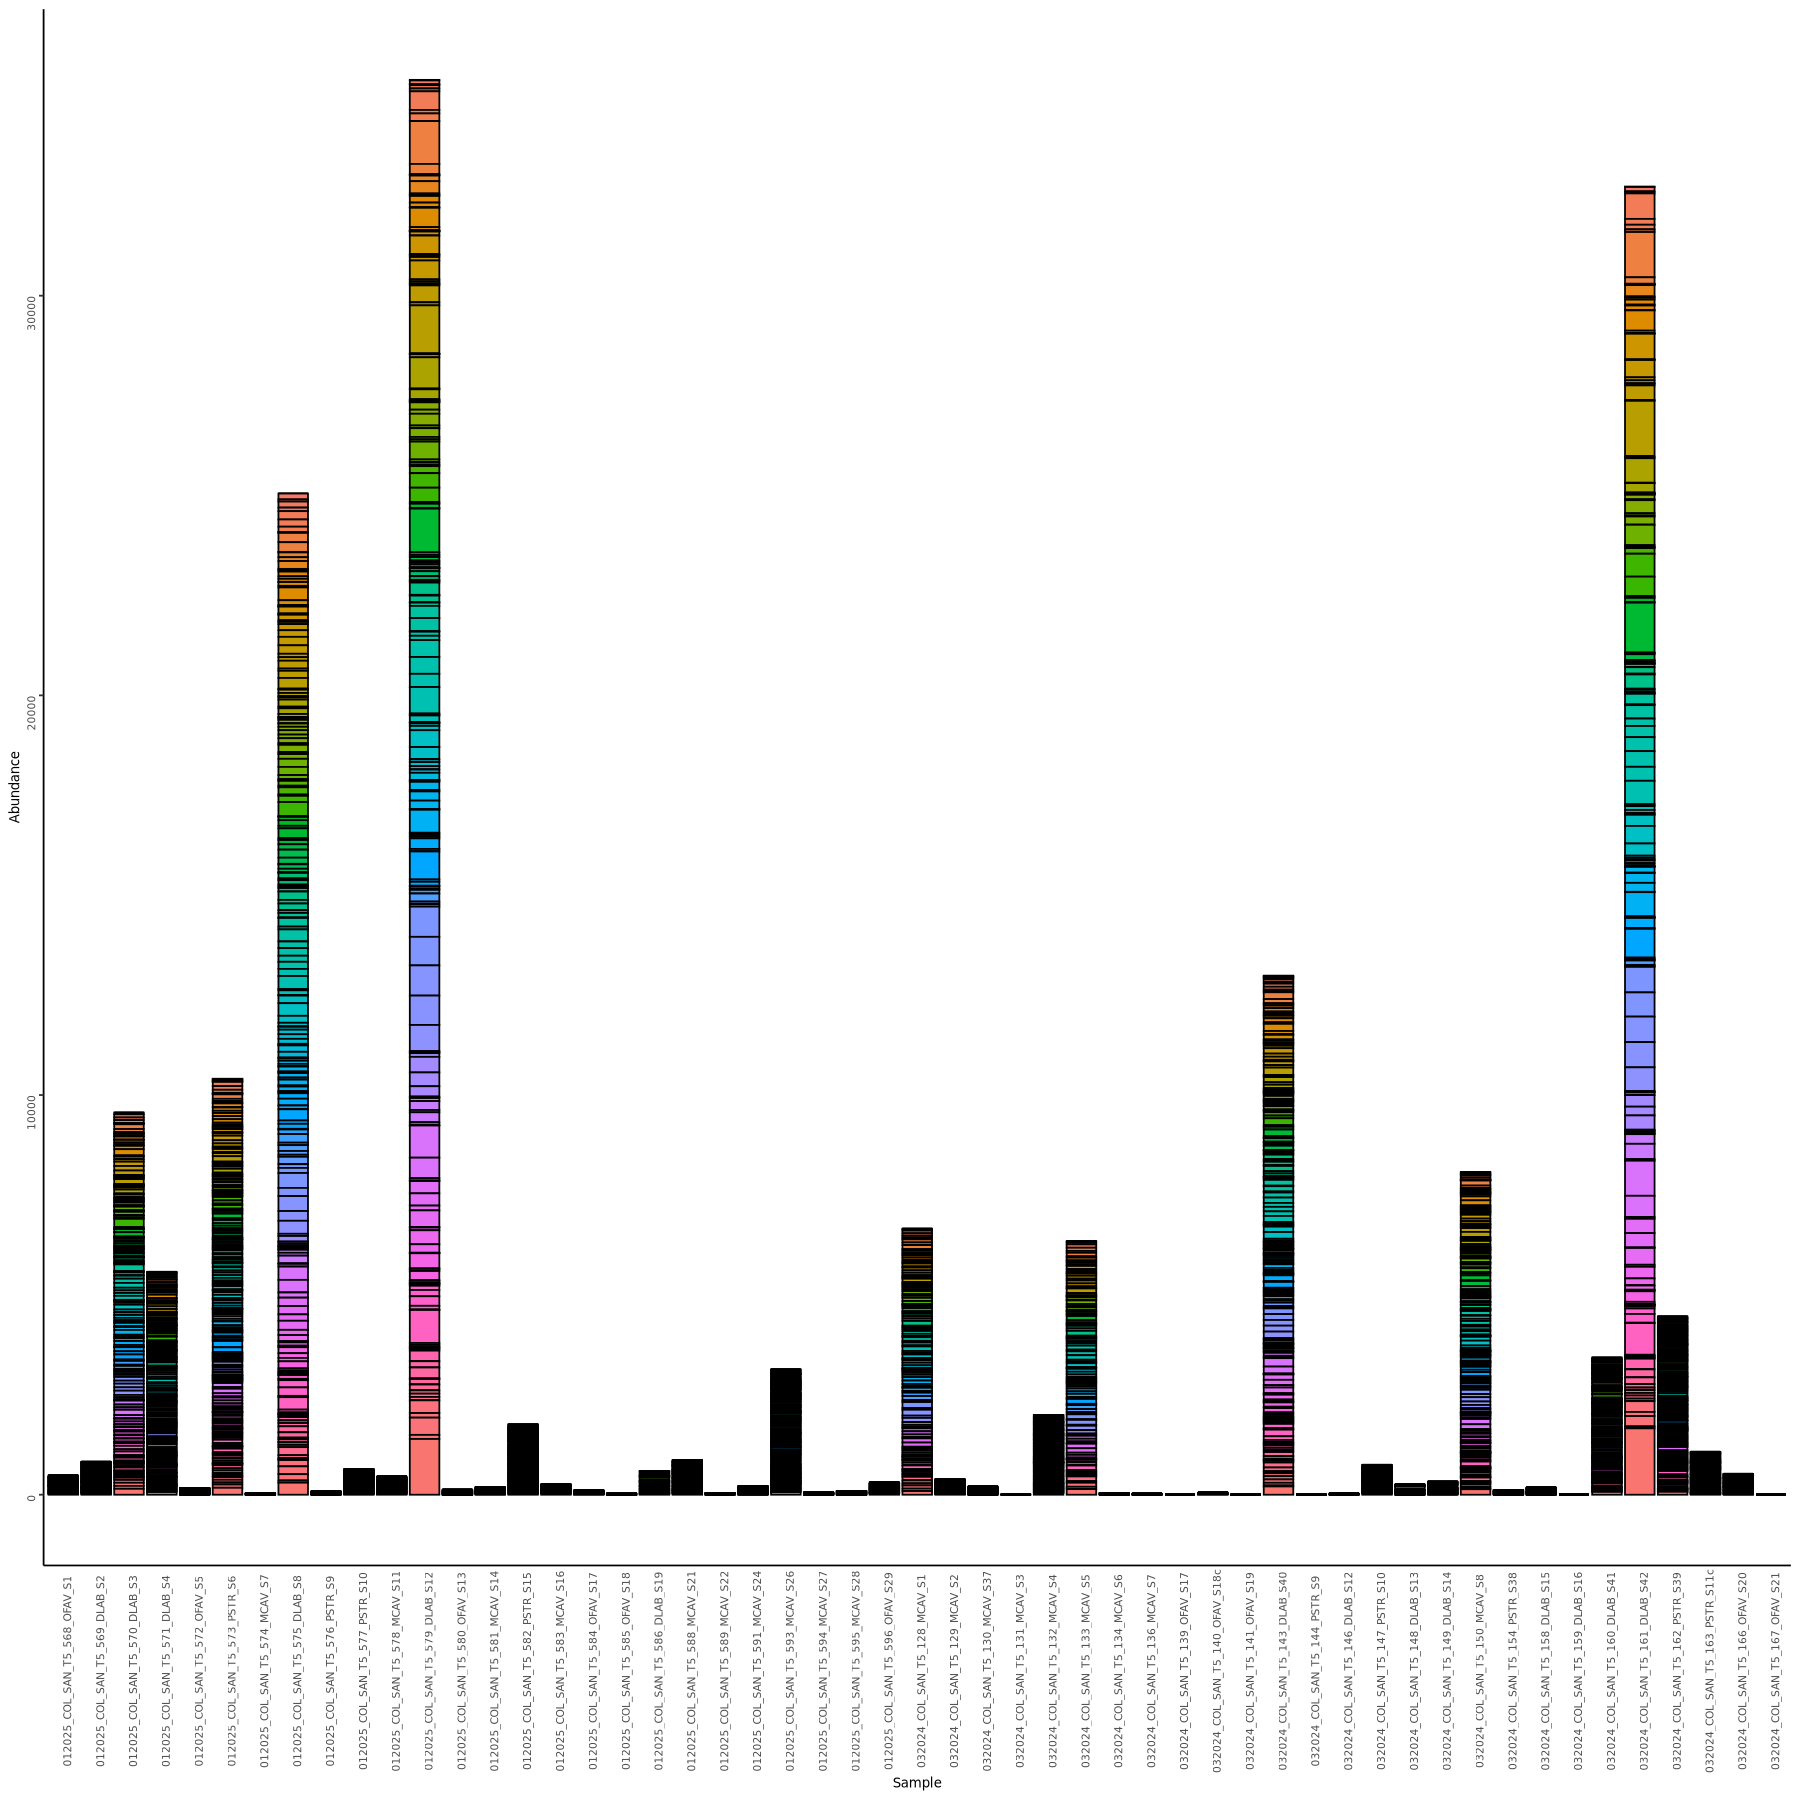

In [18]:
pathway_plot<- df_pathway_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position = "none", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(),
          panel.grid.minor.y = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=8))
pathway_plot

### Combine samples of same coral species and sample year together

In [19]:
#combine samples into 012025 and 032024 groupings for each species
# Summing specific columns by name
pathway_totals <- as.data.frame(pathways_filt_reordered)
pathway_totals$OFAV_032024 <- rowSums(pathways_filt_reordered[, c("032024_COL_SAN_T5_139_OFAV_S17","032024_COL_SAN_T5_140_OFAV_S18c",
                                                                 "032024_COL_SAN_T5_141_OFAV_S19","032024_COL_SAN_T5_166_OFAV_S20",
                                                                 "032024_COL_SAN_T5_167_OFAV_S21")], 
                          na.rm = TRUE)
pathway_totals$OFAV_012025 <- rowSums(pathways_filt_reordered[, c("012025_COL_SAN_T5_568_OFAV_S1","012025_COL_SAN_T5_572_OFAV_S5",
                                                                  "012025_COL_SAN_T5_580_OFAV_S13","012025_COL_SAN_T5_584_OFAV_S17",
                                                                  "012025_COL_SAN_T5_585_OFAV_S18","012025_COL_SAN_T5_596_OFAV_S29")], 
                          na.rm = TRUE)
pathway_totals$MCAV_032024 <- rowSums(pathways_filt_reordered[, c("032024_COL_SAN_T5_128_MCAV_S1","032024_COL_SAN_T5_129_MCAV_S2",
                                                                  "032024_COL_SAN_T5_130_MCAV_S37","032024_COL_SAN_T5_131_MCAV_S3",
                                                                  "032024_COL_SAN_T5_132_MCAV_S4","032024_COL_SAN_T5_133_MCAV_S5",
                                                                  "032024_COL_SAN_T5_134_MCAV_S6","032024_COL_SAN_T5_136_MCAV_S7",
                                                                  "032024_COL_SAN_T5_150_MCAV_S8")], 
                          na.rm = TRUE)
pathway_totals$MCAV_012025 <- rowSums(pathways_filt_reordered[, c("012025_COL_SAN_T5_574_MCAV_S7","012025_COL_SAN_T5_578_MCAV_S11",
                                                                  "012025_COL_SAN_T5_581_MCAV_S14","012025_COL_SAN_T5_583_MCAV_S16",
                                                                  "012025_COL_SAN_T5_588_MCAV_S21","012025_COL_SAN_T5_589_MCAV_S22",
                                                                  "012025_COL_SAN_T5_591_MCAV_S24","012025_COL_SAN_T5_593_MCAV_S26",
                                                                  "012025_COL_SAN_T5_594_MCAV_S27","012025_COL_SAN_T5_595_MCAV_S28")], 
                          na.rm = TRUE)
pathway_totals$DLAB_032024 <- rowSums(pathways_filt_reordered[, c("032024_COL_SAN_T5_146_DLAB_S12","032024_COL_SAN_T5_148_DLAB_S13",
                                                                  "032024_COL_SAN_T5_149_DLAB_S14","032024_COL_SAN_T5_158_DLAB_S15",
                                                                  "032024_COL_SAN_T5_159_DLAB_S16","032024_COL_SAN_T5_143_DLAB_S40",
                                                                  "032024_COL_SAN_T5_160_DLAB_S41","032024_COL_SAN_T5_161_DLAB_S42")], 
                          na.rm = TRUE)
pathway_totals$DLAB_012025 <- rowSums(pathways_filt_reordered[, c("012025_COL_SAN_T5_569_DLAB_S2","012025_COL_SAN_T5_570_DLAB_S3",
                                                                  "012025_COL_SAN_T5_571_DLAB_S4","012025_COL_SAN_T5_575_DLAB_S8",
                                                                  "012025_COL_SAN_T5_579_DLAB_S12","012025_COL_SAN_T5_586_DLAB_S19")], 
                          na.rm = TRUE)
pathway_totals$PSTR_032024 <- rowSums(pathways_filt_reordered[, c("032024_COL_SAN_T5_144_PSTR_S9","032024_COL_SAN_T5_147_PSTR_S10",
                                                                 "032024_COL_SAN_T5_163_PSTR_S11c","032024_COL_SAN_T5_154_PSTR_S38",
                                                                 "032024_COL_SAN_T5_162_PSTR_S39")], 
                          na.rm = TRUE)
pathway_totals$PSTR_012025 <- rowSums(pathways_filt_reordered[, c("012025_COL_SAN_T5_573_PSTR_S6","012025_COL_SAN_T5_576_PSTR_S9",
                                                                 "012025_COL_SAN_T5_577_PSTR_S10","012025_COL_SAN_T5_582_PSTR_S15")], 
                          na.rm = TRUE)

head(pathway_totals)

,Pathway,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,⋯,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,OFAV_032024,OFAV_012025,MCAV_032024,MCAV_012025,DLAB_032024,DLAB_012025,PSTR_032024,PSTR_012025
,<chr>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
7,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0,0,0,0,0,0,0,0,0,⋯,0,0.00000,0,0,0.00000,0.00000,22.42611,0.00000,0.00000,5.85254
9,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0,0,0,0,0,0,0,0,0,⋯,0,0.00000,0,0,0.00000,0.00000,27.51115,14.05816,0.00000,0.00000
11,1CMET2-PWY: folate transformations III (E. coli),0,0,0,0,0,0,0,0,0,⋯,0,19.79318,0,0,14.09569,0.00000,157.14099,298.22022,30.61857,19.79318
15,ANAEROFRUCAT-PWY: homolactic fermentation,0,0,0,0,0,0,0,0,0,⋯,0,0.00000,0,0,84.82049,16.82042,48.70286,95.34656,0.00000,18.35070
17,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0,0,0,0,0,0,0,0,0,⋯,0,0.00000,0,0,187.39269,34.52671,127.94512,274.91684,0.00000,27.56371
19,ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,0,0,0,0,0,0,0,0,0,⋯,0,0.00000,0,0,0.00000,0.00000,0.00000,0.00000,0.00000,18.08326


In [20]:
#then remove the samples and just have the totals
pathway_totals_ready <- pathway_totals %>% select(-contains("_SAN_T5_"))
head(pathway_totals_ready)

,Pathway,OFAV_032024,OFAV_012025,MCAV_032024,MCAV_012025,DLAB_032024,DLAB_012025,PSTR_032024,PSTR_012025
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
7,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0,0,0.00000,0.00000,22.42611,0.00000,0.00000,5.85254
9,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0,0,0.00000,0.00000,27.51115,14.05816,0.00000,0.00000
11,1CMET2-PWY: folate transformations III (E. coli),0,0,14.09569,0.00000,157.14099,298.22022,30.61857,19.79318
15,ANAEROFRUCAT-PWY: homolactic fermentation,0,0,84.82049,16.82042,48.70286,95.34656,0.00000,18.35070
17,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0,0,187.39269,34.52671,127.94512,274.91684,0.00000,27.56371
19,ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,0,0,0.00000,0.00000,0.00000,0.00000,0.00000,18.08326


In [21]:
df_pathway_totals_long <- pathway_totals_ready %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

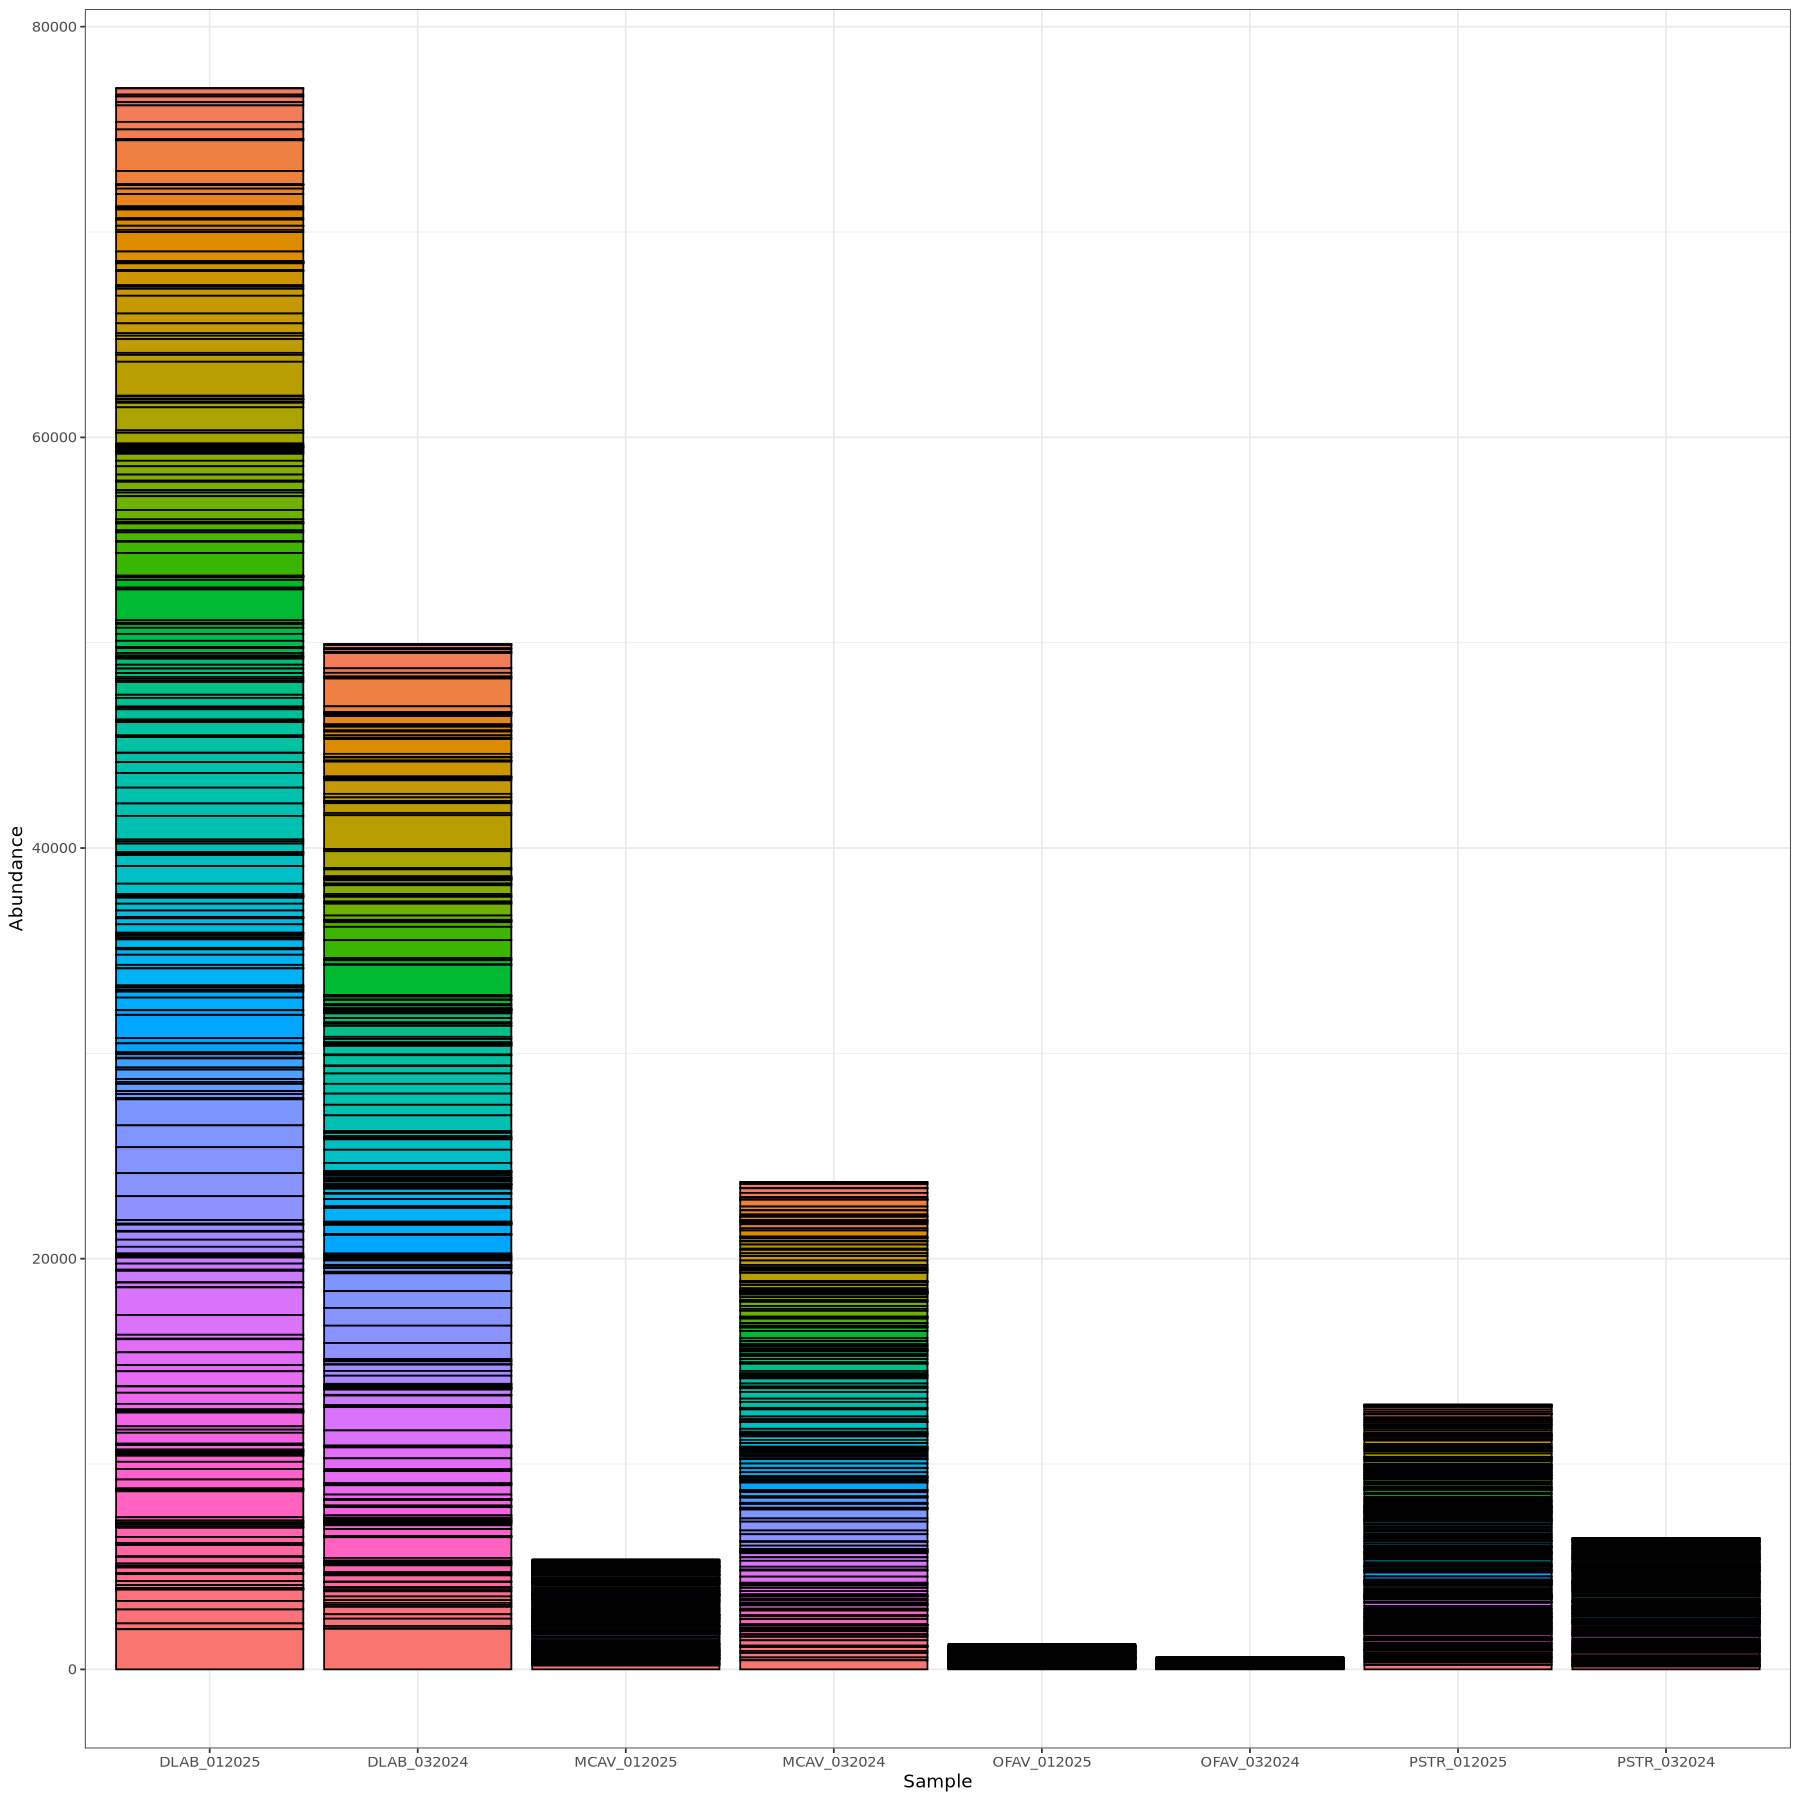

In [22]:
coral_pathway_plot<- df_pathway_totals_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw()+
  theme(legend.position = "none")
coral_pathway_plot

### OFAVs

In [75]:
#look at just ofavs
ofav_pathways <- subset(pathway_totals_ready, select = c(Pathway, OFAV_032024, OFAV_012025))
head(ofav_pathways)
#remove rows with zeros (in columns 2 and 3)
ofav_pathways_num <- ofav_pathways[rowSums(ofav_pathways[, c(2,3)] == 0) < 2, ]
head(ofav_pathways_num)
dim(ofav_pathways_num)

,Pathway,OFAV_032024,OFAV_012025
,<chr>,<dbl>,<dbl>
7,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0,0
9,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0,0
11,1CMET2-PWY: folate transformations III (E. coli),0,0
15,ANAEROFRUCAT-PWY: homolactic fermentation,0,0
17,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0,0
19,ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,0,0


,Pathway,OFAV_032024,OFAV_012025
,<chr>,<dbl>,<dbl>
21,ARGININE-SYN4-PWY: L-ornithine biosynthesis II,4.091661,0.000000
40,BRANCHED-CHAIN-AA-SYN-PWY: superpathway of branched chain amino acid biosynthesis,0.000000,50.755748
44,CALVIN-PWY: Calvin-Benson-Bassham cycle,0.000000,21.755789
60,COA-PWY: coenzyme A biosynthesis I (prokaryotic),12.219949,8.415631
82,FASYN-ELONG-PWY: fatty acid elongation -- saturated,23.179943,14.048183
111,GLUTORN-PWY: L-ornithine biosynthesis I,5.772511,12.215351


[1] 82  3

In [24]:
df_pathway_ofav_long <- ofav_pathways_num %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

In [87]:
options(repr.plot.width=10, repr.plot.height=10)

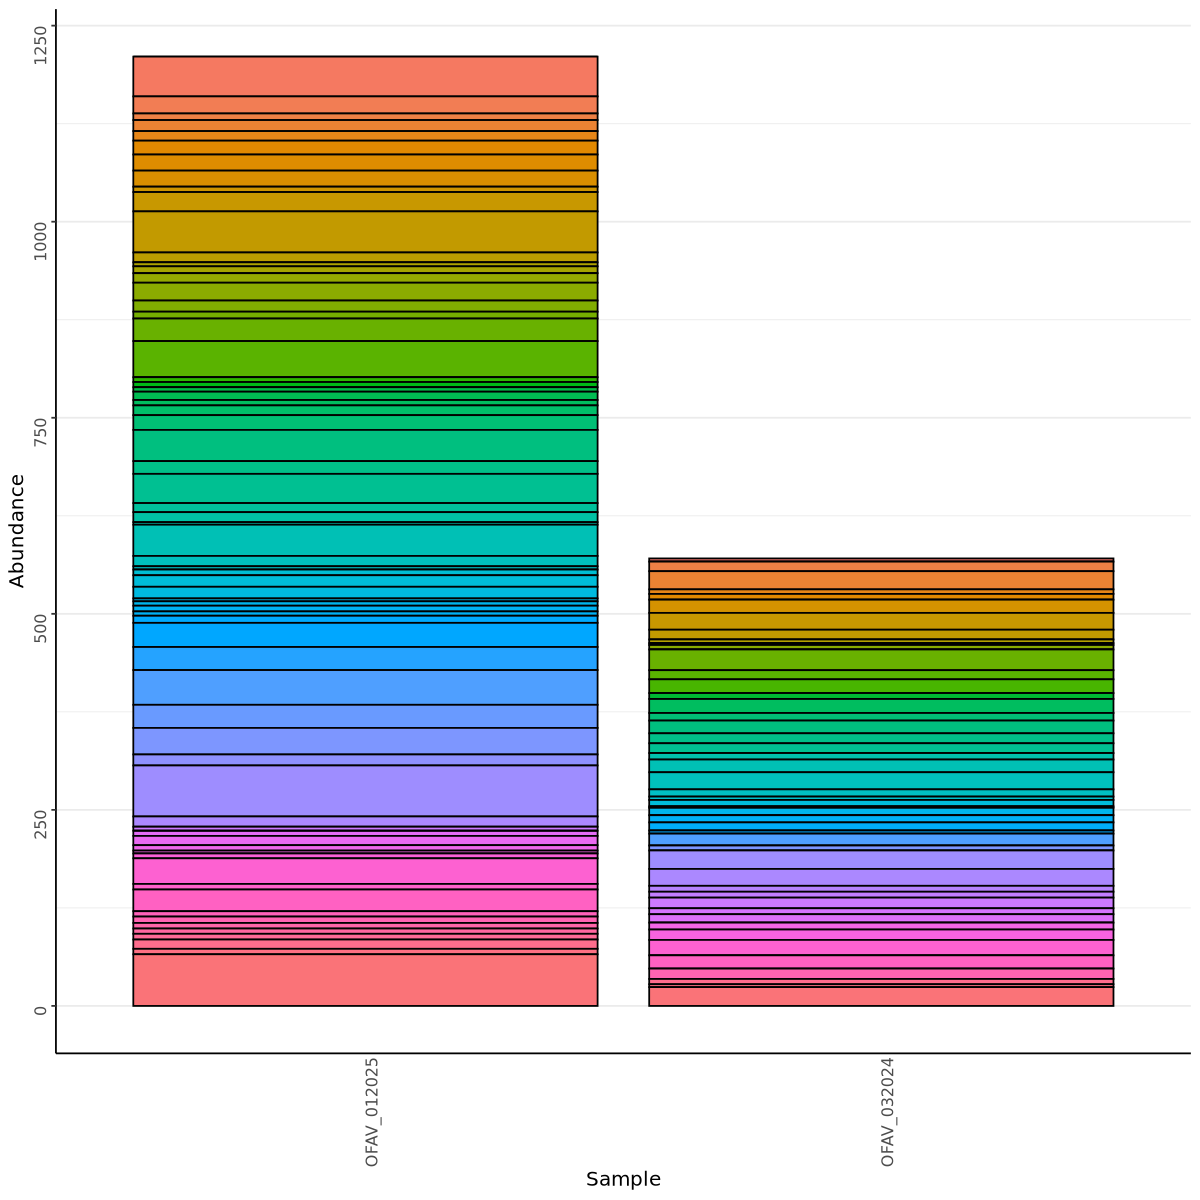

In [89]:
ofav_pathway_plot<- df_pathway_ofav_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position="none", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12)) 
#legend.key.size = unit(0.1, "cm"))+
#theme(aspect.ratio = 1.5)

ofav_pathway_plot

In [59]:
# index the Pathways
row.names(ofav_pathways_num) <- ofav_pathways_num$Pathway
ofav_pathways_num$Pathway <- NULL
head(ofav_pathways_num)

,OFAV_032024,OFAV_012025
,<dbl>,<dbl>
ARGININE-SYN4-PWY: L-ornithine biosynthesis II,4.091661,0.000000
BRANCHED-CHAIN-AA-SYN-PWY: superpathway of branched chain amino acid biosynthesis,0.000000,50.755748
CALVIN-PWY: Calvin-Benson-Bassham cycle,0.000000,21.755789
COA-PWY: coenzyme A biosynthesis I (prokaryotic),12.219949,8.415631
FASYN-ELONG-PWY: fatty acid elongation -- saturated,23.179943,14.048183
GLUTORN-PWY: L-ornithine biosynthesis I,5.772511,12.215351


In [60]:
# Convert to matrix
ofav_pathways_matrix=as.matrix(ofav_pathways_num)
head(ofav_pathways_matrix)

,OFAV_032024,OFAV_012025
ARGININE-SYN4-PWY: L-ornithine biosynthesis II,4.091661,0.000000
BRANCHED-CHAIN-AA-SYN-PWY: superpathway of branched chain amino acid biosynthesis,0.000000,50.755748
CALVIN-PWY: Calvin-Benson-Bassham cycle,0.000000,21.755789
COA-PWY: coenzyme A biosynthesis I (prokaryotic),12.219949,8.415631
FASYN-ELONG-PWY: fatty acid elongation -- saturated,23.179943,14.048183
GLUTORN-PWY: L-ornithine biosynthesis I,5.772511,12.215351


In [61]:
#calculate totals
pathway_totals <- rowSums(ofav_pathways_matrix)

In [62]:
#take the top 20 pathways
ofav_top_20 <- order(pathway_totals, decreasing = TRUE)[1:20]
head(ofav_top_20)

[1] 82 59 13 55 24 34

In [77]:
#need to do this from an unindexed dataframe, so re-run step where I first make the ofav_pathways_num df
    #before doing this part!
#pull the top 20 out of the full matrix
ofav_top_20_m <- ofav_pathways_num[ofav_top_20, ]
head(ofav_top_20_m)

,Pathway,OFAV_032024,OFAV_012025
,<chr>,<dbl>,<dbl>
864,VALSYN-PWY: L-valine biosynthesis,23.99349,65.86406
675,PWY-7663: gondoate biosynthesis (anaerobic),23.52664,65.04449
152,ILEUSYN-PWY: L-isoleucine biosynthesis I (from threonine),12.48060,52.38511
595,PWY-7221: guanosine ribonucleotides de novo biosynthesis,15.12535,44.28594
287,PWY-5103: L-isoleucine biosynthesis III,11.65263,46.09521
398,PWY-6122: 5-aminoimidazole ribonucleotide biosynthesis II,16.23287,39.80298


In [78]:
df_pathway_ofav_20_long <- ofav_top_20_m %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

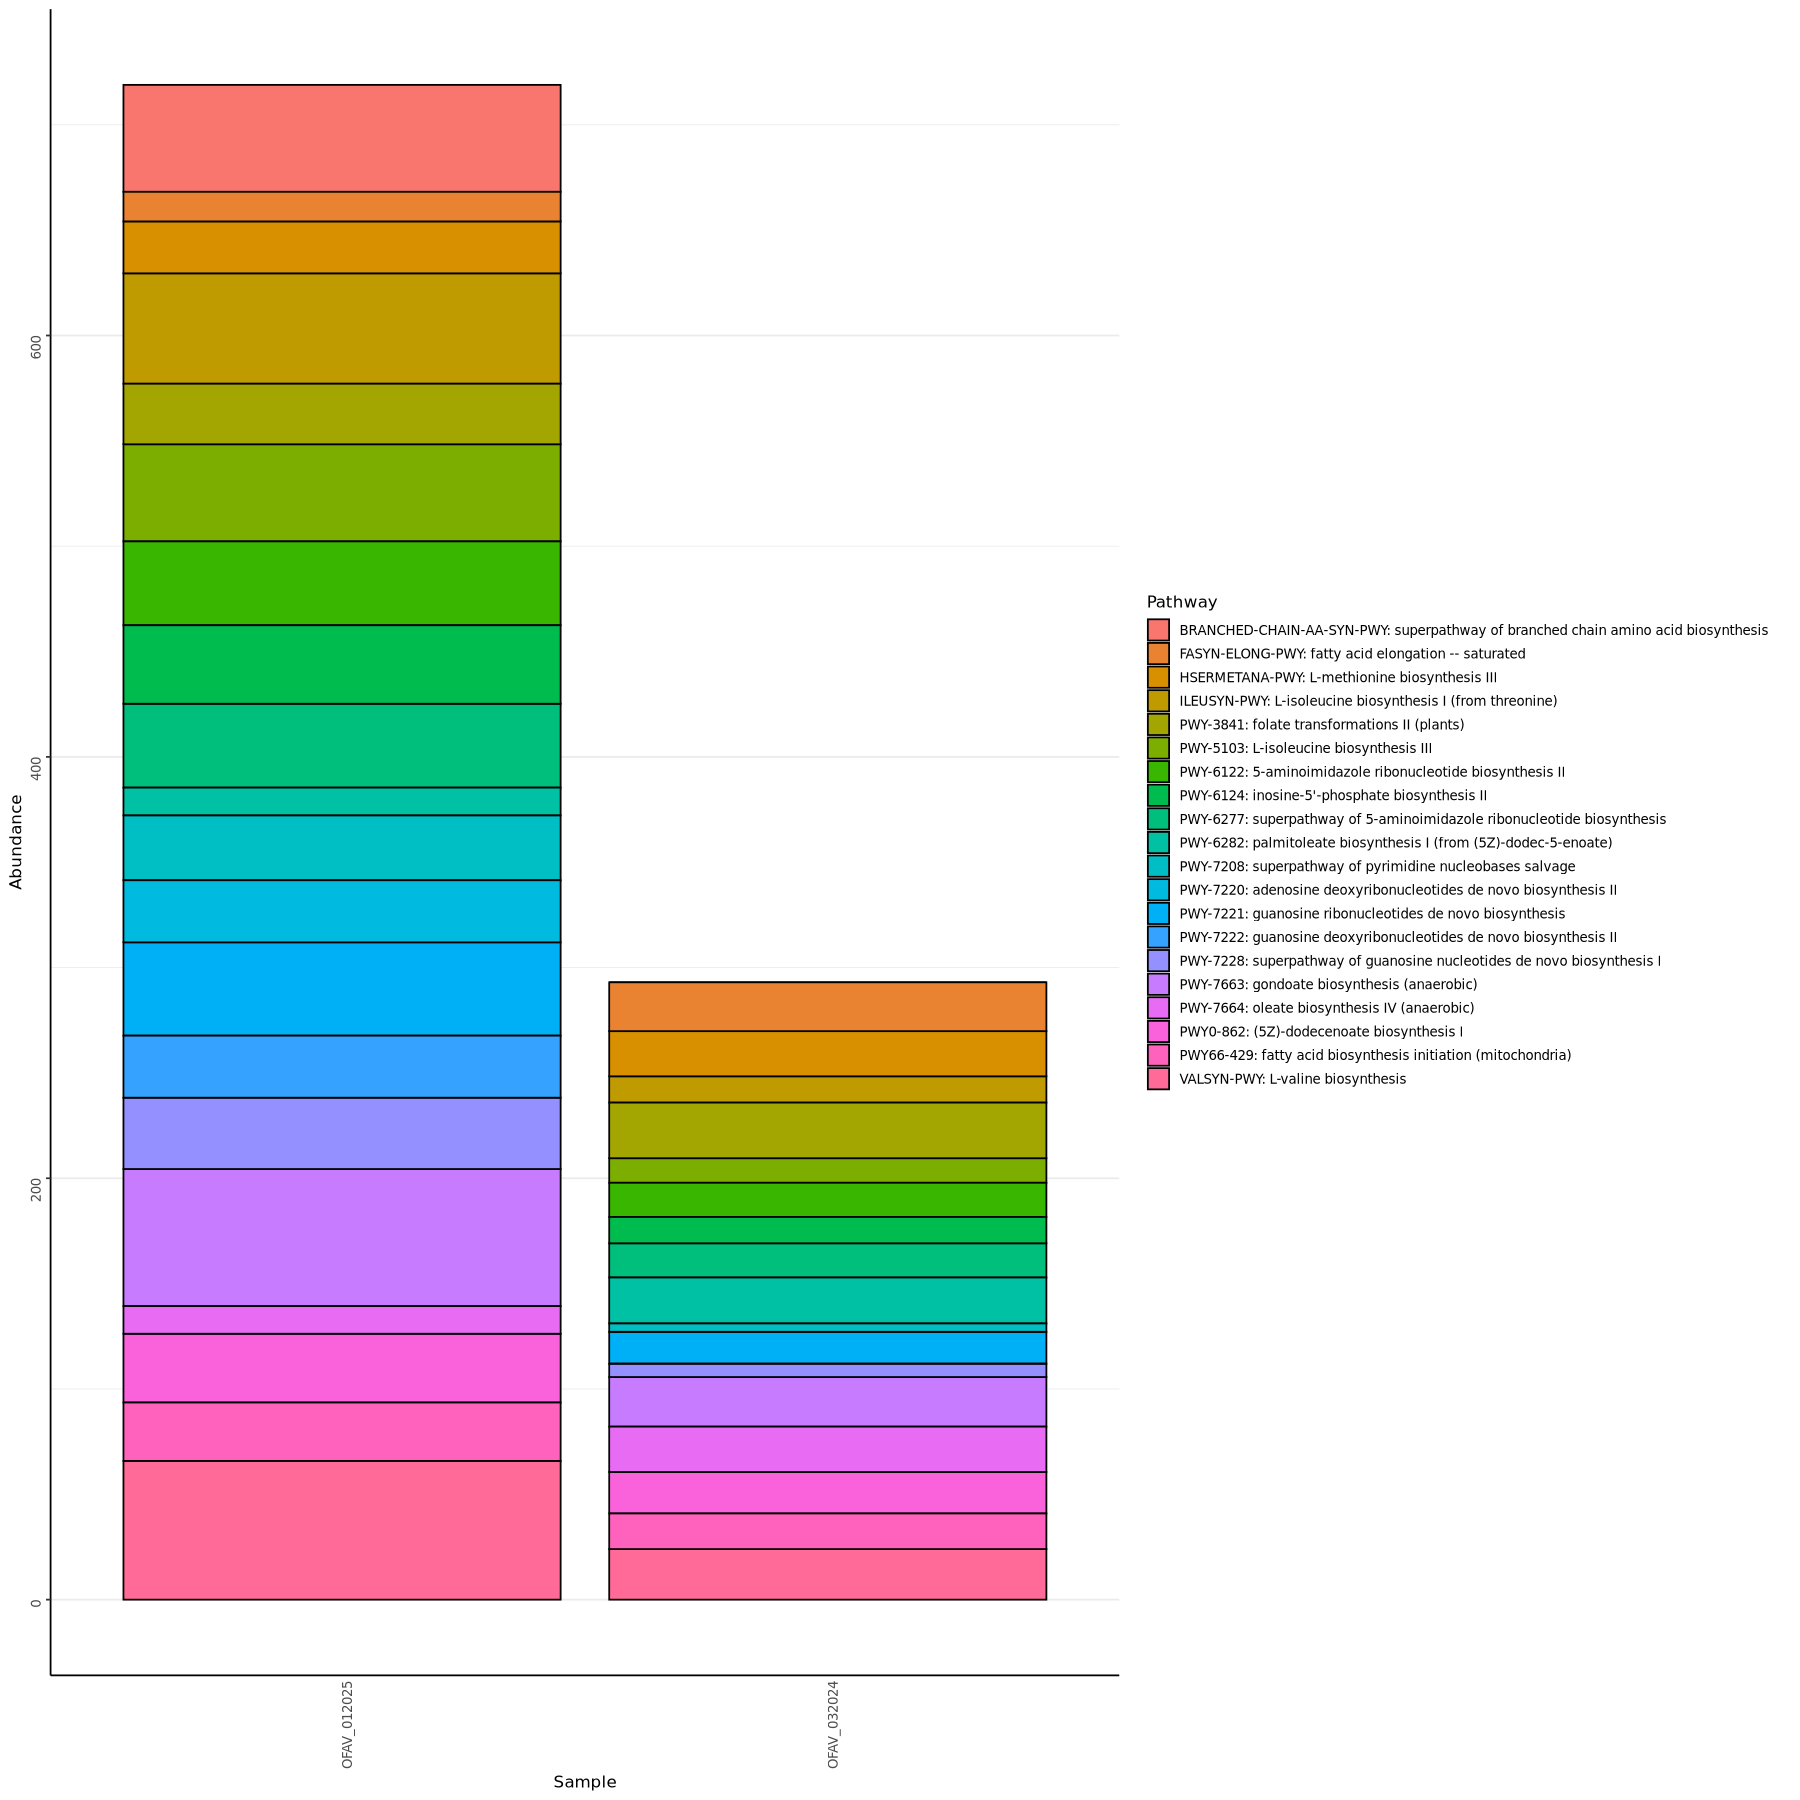

In [83]:
ofav_pathway_plot_20<- df_pathway_ofav_20_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position="right", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=10), legend.key.size = unit(0.5, "cm"))
#theme(aspect.ratio = 1.5)

ofav_pathway_plot_20

### MCAVs

In [97]:
#look at just mcavs
mcav_pathways <- subset(pathway_totals_ready, select = c(Pathway, MCAV_032024, MCAV_012025))
head(mcav_pathways)
#remove rows with zeros (in columns 2 and 3)
mcav_pathways_num <- mcav_pathways[rowSums(mcav_pathways[, c(2,3)] == 0) < 2, ]
head(mcav_pathways_num)
dim(mcav_pathways_num)

,Pathway,MCAV_032024,MCAV_012025
,<chr>,<dbl>,<dbl>
7,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0.00000,0.00000
9,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0.00000,0.00000
11,1CMET2-PWY: folate transformations III (E. coli),14.09569,0.00000
15,ANAEROFRUCAT-PWY: homolactic fermentation,84.82049,16.82042
17,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),187.39269,34.52671
19,ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,0.00000,0.00000


,Pathway,MCAV_032024,MCAV_012025
,<chr>,<dbl>,<dbl>
11,1CMET2-PWY: folate transformations III (E. coli),14.09569,0.00000
15,ANAEROFRUCAT-PWY: homolactic fermentation,84.82049,16.82042
17,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),187.39269,34.52671
21,ARGININE-SYN4-PWY: L-ornithine biosynthesis II,19.21916,0.00000
24,ARGSYN-PWY: L-arginine biosynthesis I (via L-ornithine),223.29933,26.06056
28,ARGSYNBSUB-PWY: L-arginine biosynthesis II (acetyl cycle),203.84770,33.15803


[1] 221   3

In [91]:
df_pathway_mcav_long <- mcav_pathways_num %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

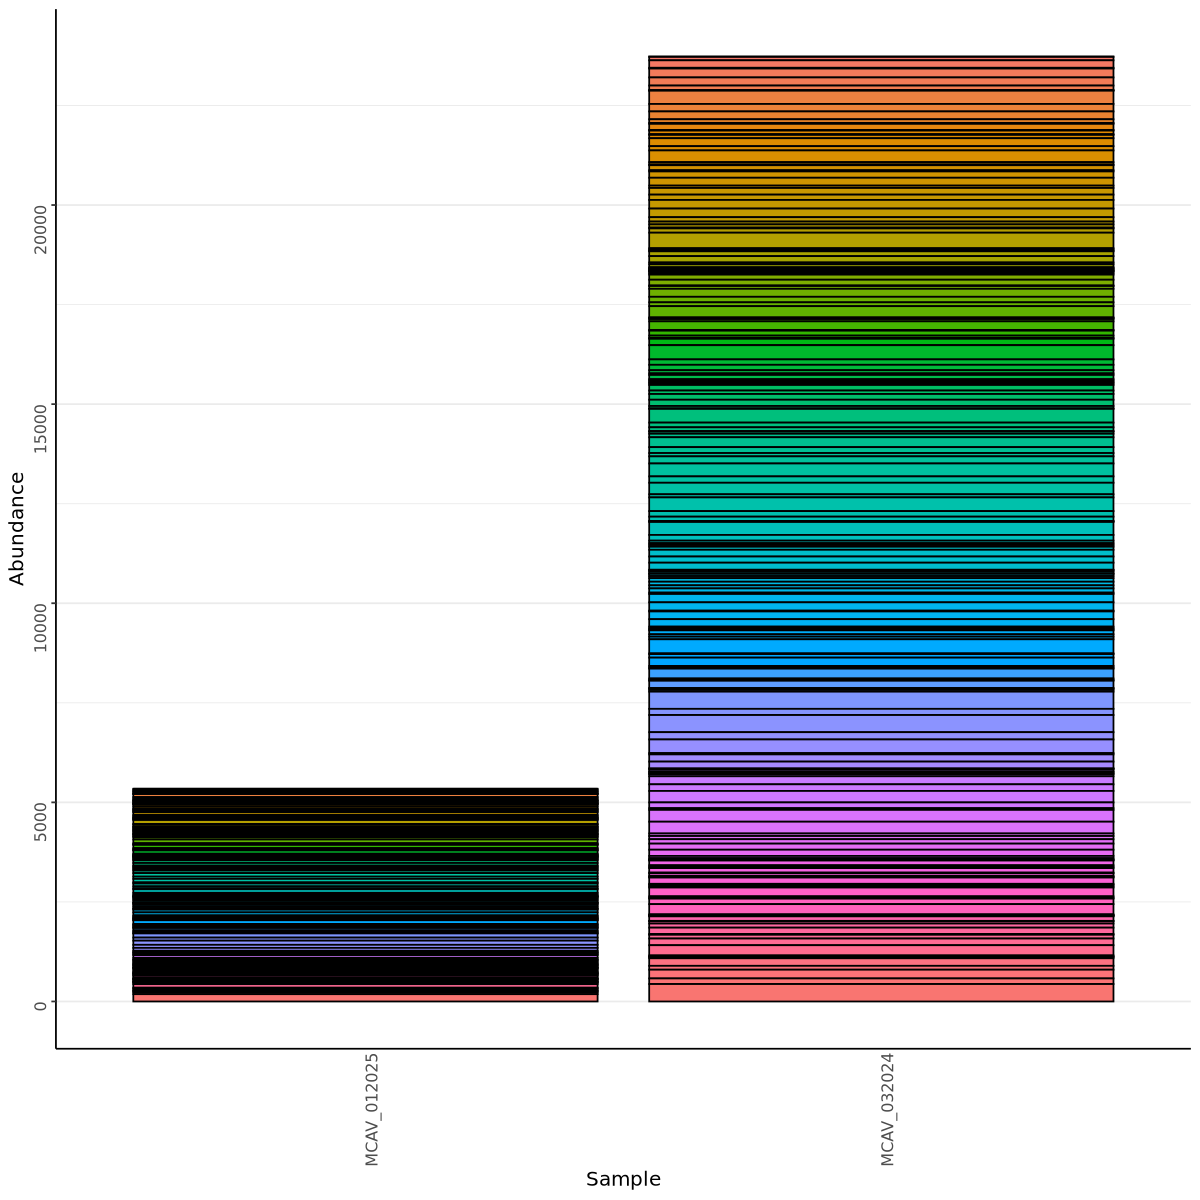

In [92]:
#without legend - need to play with sizing
mcav_pathway_plot_l<- df_pathway_mcav_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position="none", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12)) 
mcav_pathway_plot_l

In [93]:
# index the Pathways
row.names(mcav_pathways_num) <- mcav_pathways_num$Pathway
mcav_pathways_num$Pathway <- NULL
head(mcav_pathways_num)

,MCAV_032024,MCAV_012025
,<dbl>,<dbl>
1CMET2-PWY: folate transformations III (E. coli),14.09569,0.00000
ANAEROFRUCAT-PWY: homolactic fermentation,84.82049,16.82042
ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),187.39269,34.52671
ARGININE-SYN4-PWY: L-ornithine biosynthesis II,19.21916,0.00000
ARGSYN-PWY: L-arginine biosynthesis I (via L-ornithine),223.29933,26.06056
ARGSYNBSUB-PWY: L-arginine biosynthesis II (acetyl cycle),203.84770,33.15803


In [94]:
# Convert to matrix
mcav_pathways_matrix=as.matrix(mcav_pathways_num)
head(mcav_pathways_matrix)

,MCAV_032024,MCAV_012025
1CMET2-PWY: folate transformations III (E. coli),14.09569,0.00000
ANAEROFRUCAT-PWY: homolactic fermentation,84.82049,16.82042
ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),187.39269,34.52671
ARGININE-SYN4-PWY: L-ornithine biosynthesis II,19.21916,0.00000
ARGSYN-PWY: L-arginine biosynthesis I (via L-ornithine),223.29933,26.06056
ARGSYNBSUB-PWY: L-arginine biosynthesis II (acetyl cycle),203.84770,33.15803


In [95]:
#calculate totals
pathway_totals_m <- rowSums(mcav_pathways_matrix)

In [96]:
#take the top 20 pathways
mcav_top_20 <- order(pathway_totals_m, decreasing = TRUE)[1:20]
head(mcav_top_20)

[1] 221 152 154  39 139  73

In [98]:
#need to do this from an unindexed dataframe, so re-run step where I first make the ofav_pathways_num df
    #before doing this part!
#pull the top 20 out of the full matrix
mcav_top_20_m <- mcav_pathways_num[mcav_top_20, ]
head(mcav_top_20_m)

,Pathway,MCAV_032024,MCAV_012025
,<chr>,<dbl>,<dbl>
864,VALSYN-PWY: L-valine biosynthesis,437.7985,182.82480
591,PWY-7220: adenosine deoxyribonucleotides de novo biosynthesis II,431.2829,104.39511
599,PWY-7222: guanosine deoxyribonucleotides de novo biosynthesis II,431.2829,104.39511
152,ILEUSYN-PWY: L-isoleucine biosynthesis I (from threonine),390.4577,97.82172
553,PWY-7111: pyruvate fermentation to isobutanol (engineered),354.2495,94.76490
287,PWY-5103: L-isoleucine biosynthesis III,356.3280,82.94952


In [99]:
df_pathway_mcav_20_long <- mcav_top_20_m %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

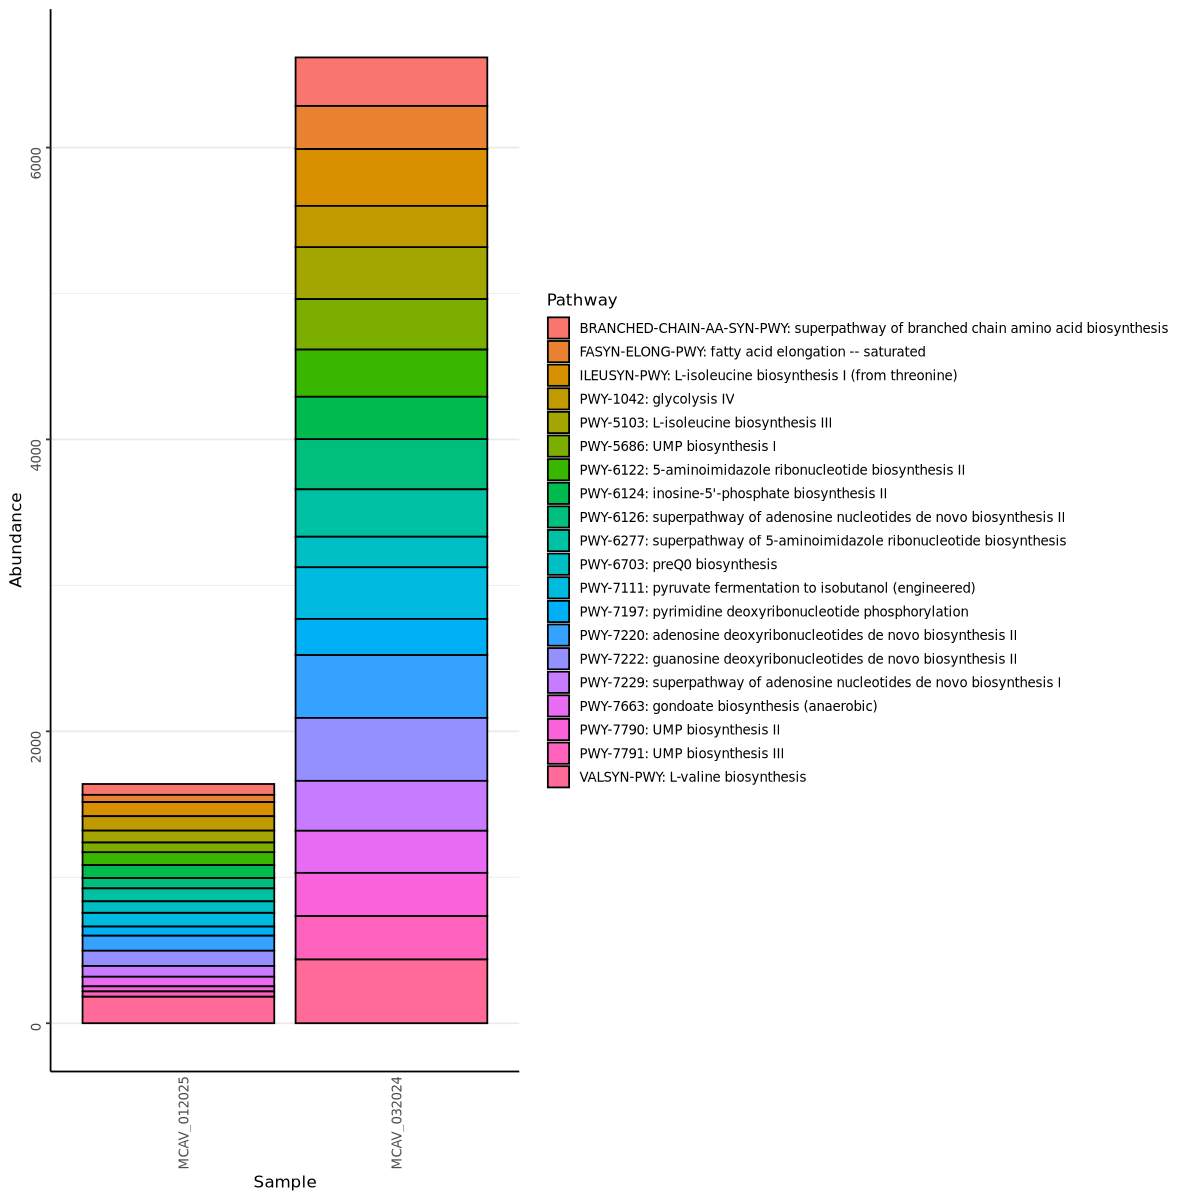

In [100]:
mcav_pathway_plot_20<- df_pathway_mcav_20_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position="right", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=10), legend.key.size = unit(0.5, "cm"))
#theme(aspect.ratio = 1.5)

mcav_pathway_plot_20

#### messsing around

In [75]:
#install.packages("cowplot")

In [68]:
library(cowplot)


Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp




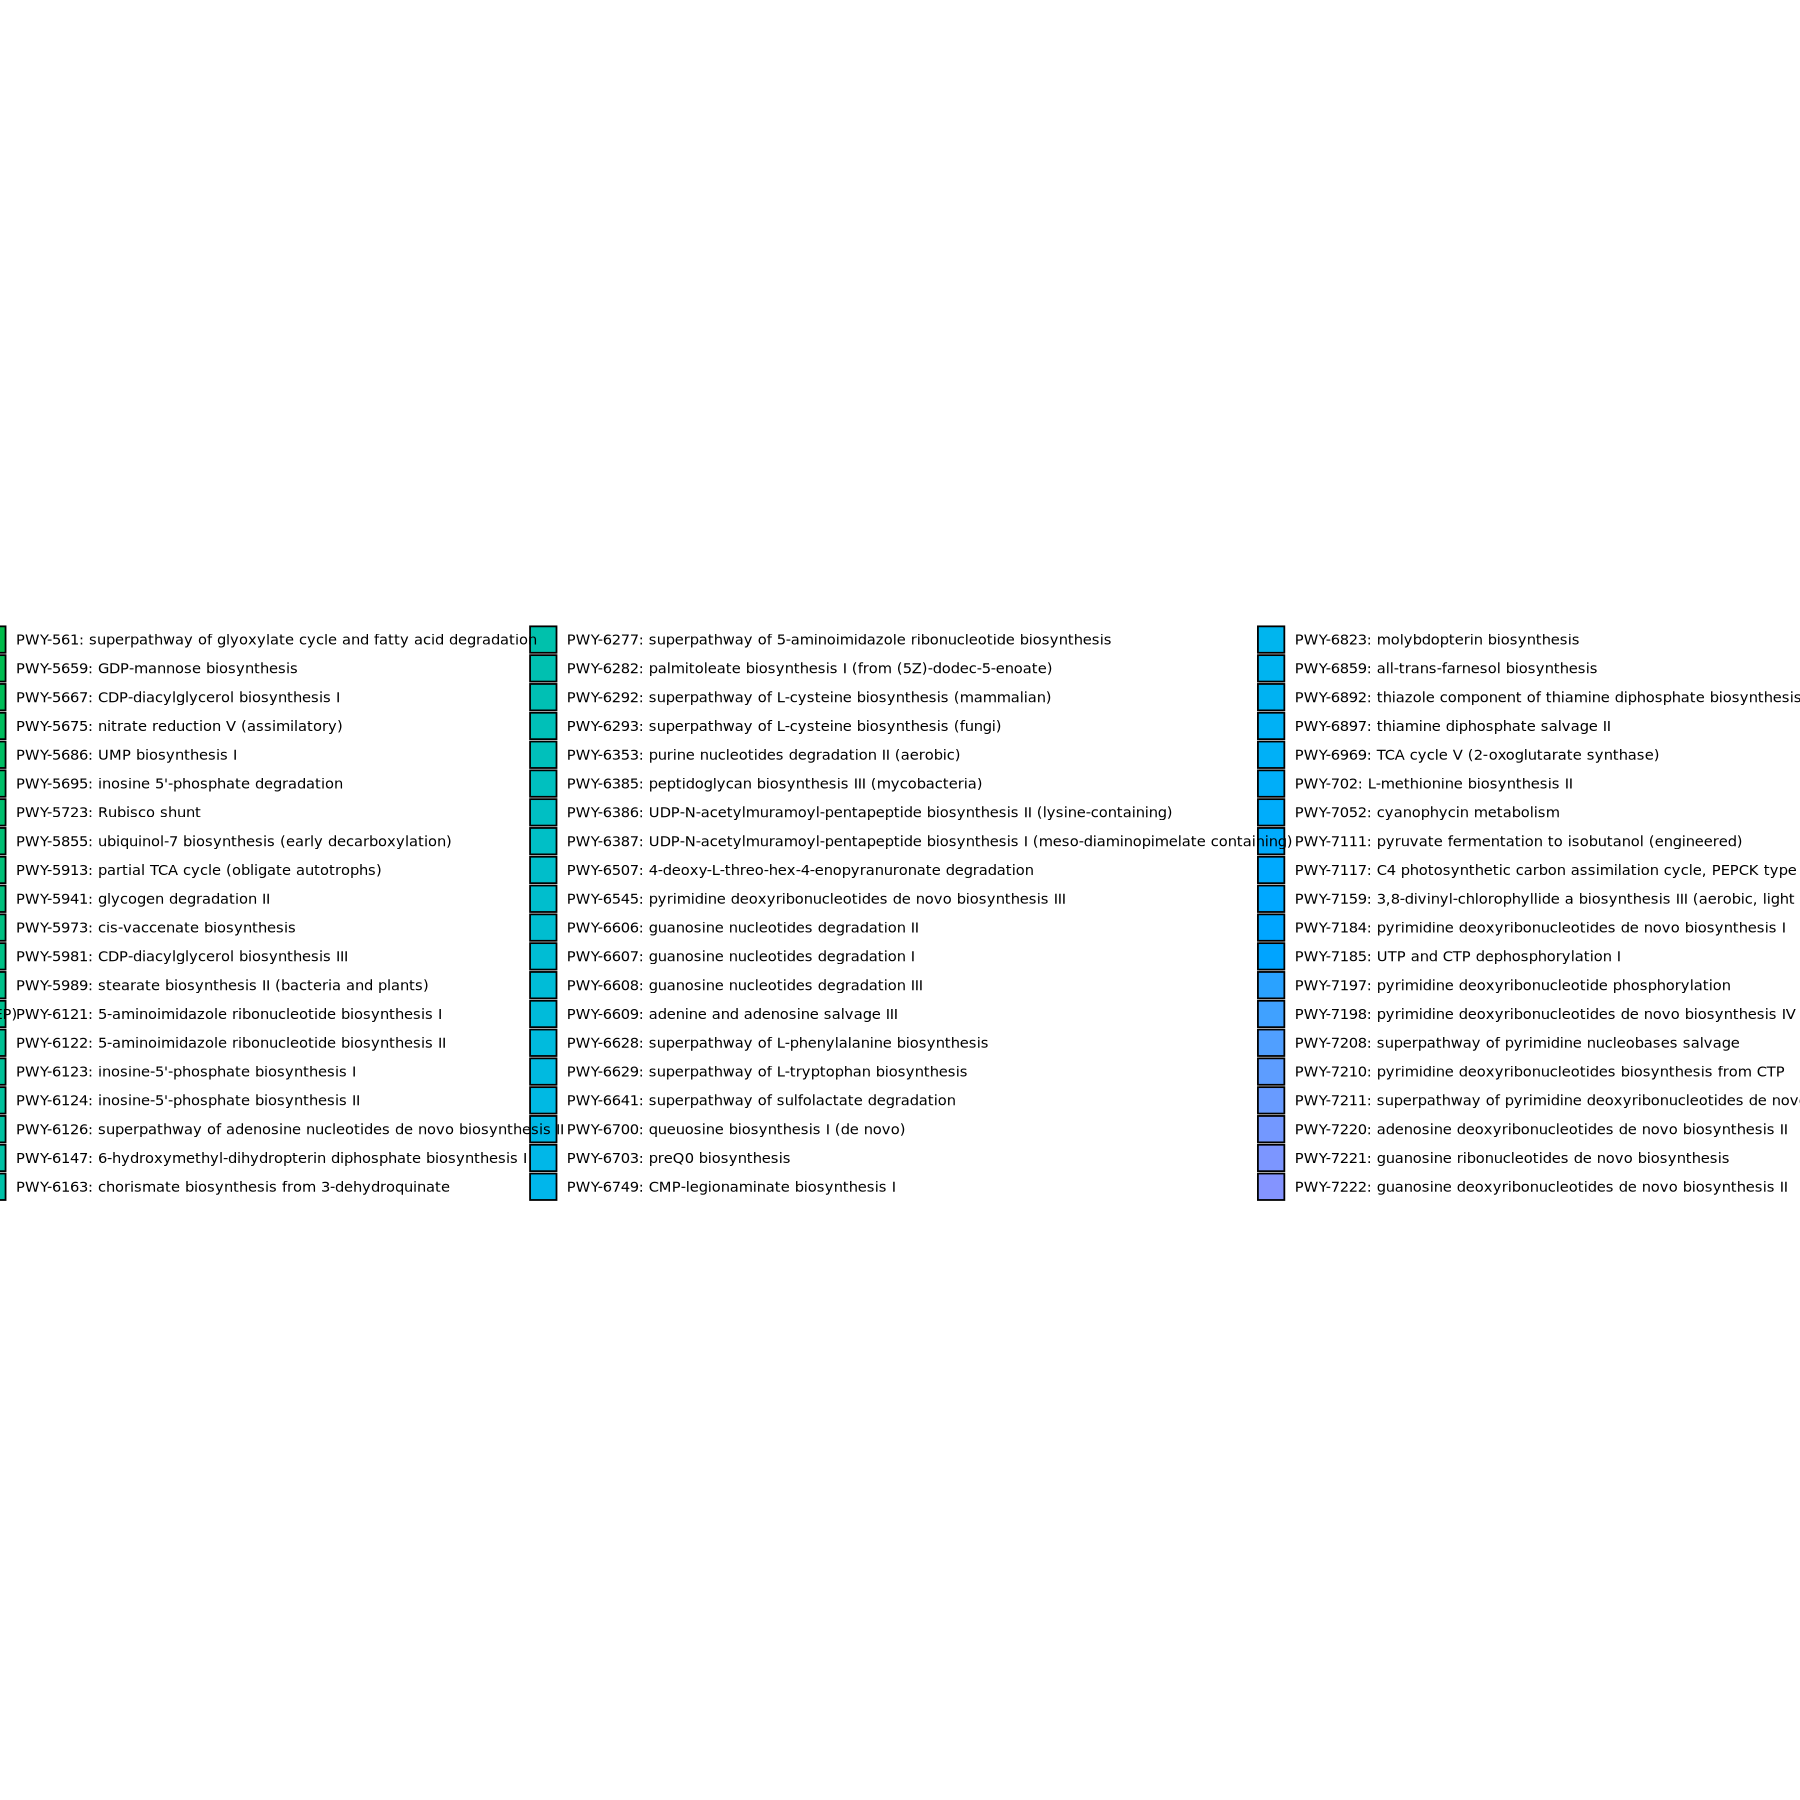

In [76]:
mcav_legend <- get_legend(mcav_pathway_plot_l)
ggdraw(mcav_legend)